In [1]:
import os
import json

# 1. Kaggle Anahtarı
kaggle_dict = {"username":"rabiayalman","key":"KGAT_be67d28192efd3990828d5fd483ea897"}
with open('kaggle.json', 'w') as f:
    json.dump(kaggle_dict, f)

# 2. Kurulum ve Veri İndirme
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install ultralytics
!kaggle datasets download -d safurahajiheidari/kidney-stone-images
!unzip -o kidney-stone-images.zip -d bobrek_verisi # -o komutu 'üzerine yaz' demektir, soru sormaz.

print("\n Adım 2 Tamamlandı: Veriler ve kütüphane hazır!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.8 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/safurahajiheidari/kidney-stone-images
License(s): other
100% 21.1M/21.1M [00:01<00:00, 16.0MB/s]

Archive:  kidney-stone-images.zip
  inflating: bobrek_verisi/README.dataset.txt  
  inflating: bobrek_verisi/README.roboflow.txt  
  inflating: bobrek_verisi/data.yaml  
  inflating: bobrek_verisi/test/images/1-3-46-670589-33-1-63703718086120120200001-5487554579919763006_png_jpg.rf.9fd67251e99a47dbe83a5db6efe6c016.jpg  
  inflating: bobrek_verisi/test/images/1-3-46-670589-33-1-63705534438365105500001-5275982036206127404_png_jpg.rf.365c4daf2b772012fe47e07b9daec86e.jpg  
  inflating: bobrek_verisi/test/images/1-3-46-670589-33-1-63705540012666937300001-5673688970564737961_png_jpg.rf.15cca2fecc5f56865de3eb405476b90d.jpg  
  inflating: bobrek_verisi/test/images/1-3-46-670589-33-1-6370554212321765

In [ ]:
from ultralytics import YOLO

# 1. YOLOv8'in başlangıç ağırlıklarını sıfırdan yüklüyoruz
model_v8_yeni = YOLO('yolov8n.pt')

# 2. 50 epoch'luk tertemiz eğitimi başlatıyoruz
results_v8_yeni = model_v8_yeni.train(
    data='/content/bobrek_verisi/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    name='yolov8_bobrek_kesin_50_epoch'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bobrek_verisi/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,

In [ ]:
from ultralytics import YOLO

print("[INFO] YOLOv8 Ağırlıkları Yükleniyor: '/content/yolov8_best.pt'...")
# Düzenlediğimiz YOLOv8 ağırlık dosyasını çağırıyoruz
model_v8_test = YOLO('/content/yolov8_best.pt')

print("[STATUS] YOLOv8 Modeli İçin Test Seti Validasyon Süreci Başlatıldı...\n")
# Aynı test seti üzerinde YOLOv8'in performansını ölçüyoruz
metrics_v8 = model_v8_test.val(data='/content/bobrek_verisi/data.yaml', split='test')

print("\n=======================================================")
print("--- METRIC ANALYSIS: YOLOv8 ARCHITECTURE TEST RESULTS ---")
print(f"Precision (Keskinlik): {metrics_v8.results_dict['metrics/precision(B)']:.4f}")
print(f"Recall (Duyarlılık)  : {metrics_v8.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP50 Skoru          : {metrics_v8.results_dict['metrics/mAP50(B)']:.4f}")
print("=======================================================")

[INFO] YOLOv8 Ağırlıkları Yükleniyor: '/content/yolov8_best.pt'...
[STATUS] YOLOv8 Modeli İçin Test Seti Validasyon Süreci Başlatıldı...

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 946.0±290.8 MB/s, size: 16.9 KB)
val: Scanning /content/bobrek_verisi/test/labels.cache... 123 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 43.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.4it/s 2.4s
                   all        123        224       0.85      0.701      0.742      0.334
Speed: 2.6ms preprocess, 4.3ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/runs/detect/val-3

--- METRIC ANALYSIS: YOLOv8 ARCHITECTURE TEST RESULTS ---
Precision (Keskinlik): 0.8495
Recall (Duyarlılık)  : 0.7009
mAP50 Skoru         

In [ ]:
# Aynı test görüntüsü üzerinde YOLOv8 mimarisinin inferans testi
results_v8_img = model_v8_test.predict(
    source='/content/bobrek_verisi/test/images/1-3-46-670589-33-1-63706052409136049800001-4885266517035478638_png_jpg.rf.403057fc6d27ba2b8a1020faf23ea6e8.jpg',
    save=True,
    imgsz=640,
    conf=0.25
)


image 1/1 /content/bobrek_verisi/test/images/1-3-46-670589-33-1-63706052409136049800001-4885266517035478638_png_jpg.rf.403057fc6d27ba2b8a1020faf23ea6e8.jpg: 544x640 1 Tas_Var, 16.2ms
Speed: 2.2ms preprocess, 16.2ms inference, 1.5ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/detect/predict-2


[INFO] YOLOv8 Sınırlayıcı Kutu çıktısı görselleştiriliyor...


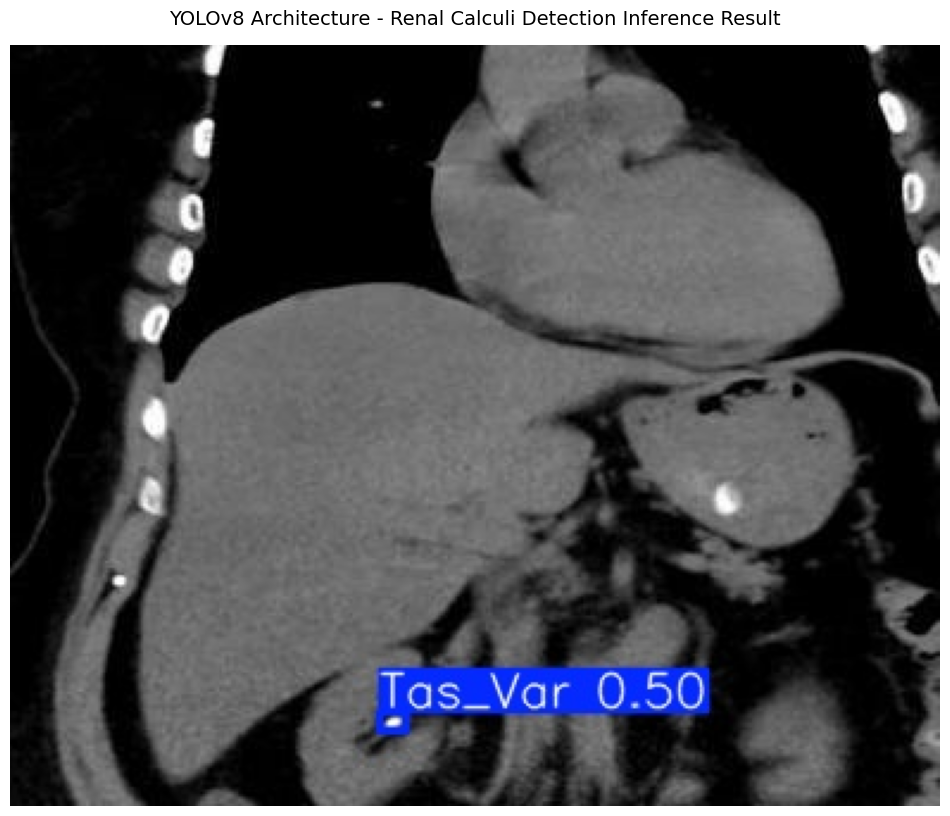

In [ ]:
import cv2
from matplotlib import pyplot as plt
import os

# YOLOv8'in en son oluşturduğu tahmin dizinini çekiyoruz
predict_folders = [f for f in os.listdir('/content/runs/detect/') if f.startswith('predict')]
predict_folders.sort()
latest_predict_folder = predict_folders[-1]
predict_dir_path = f'/content/runs/detect/{latest_predict_folder}/'

image_files = [f for f in os.listdir(predict_dir_path) if f.endswith('.jpg')]
if image_files:
    full_image_path = os.path.join(predict_dir_path, image_files[0])

    print("[INFO] YOLOv8 Sınırlayıcı Kutu çıktısı görselleştiriliyor...")

    image = cv2.imread(full_image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 10))
    plt.imshow(image)
    plt.title('YOLOv8 Architecture - Renal Calculi Detection Inference Result', fontsize=14, pad=15)
    plt.axis('off')
    plt.show()

In [ ]:
from ultralytics import YOLO

# 1. YOLOv10'un kararlı ve resmi sürümünü yüklüyoruz
model_v10 = YOLO('yolov10n.pt')

# 2. 50 epoch'luk taptaze YOLOv10 eğitimini başlatıyoruz
results_v10 = model_v10.train(
    data='/content/bobrek_verisi/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    name='yolov10_bobrek_kesin_50_epoch'
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bobrek_verisi/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10_bobrek_kesin_50_epoch, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

In [ ]:
# YOLOv10'un taze biten eğitim metriklerini doğrudan test seti üzerinde ölçüyoruz
metrics_v10 = model_v10.val(data='/content/bobrek_verisi/data.yaml', split='test')

print("\n=========================================")
print("--- YOLOv10 GERÇEK TEST METRİKLERİ ---")
print("Precision (Keskinlik):", metrics_v10.results_dict['metrics/precision(B)'])
print("Recall (Duyarlılık):", metrics_v10.results_dict['metrics/recall(B)'])
print("mAP50 Skoru:", metrics_v10.results_dict['metrics/mAP50(B)'])
print("=========================================")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 102 layers, 2,265,363 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 903.3±324.0 MB/s, size: 17.1 KB)
val: Scanning /content/bobrek_verisi/test/labels.cache... 123 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 36.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.5it/s 2.3s
                   all        123        224      0.754      0.625      0.715      0.317
Speed: 4.0ms preprocess, 4.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/val-2

--- YOLOv10 GERÇEK TEST METRİKLERİ ---
Precision (Keskinlik): 0.7538969369693763
Recall (Duyarlılık): 0.625
mAP50 Skoru: 0.7152165328776727


In [ ]:
# Seçtiğin bir test resmi üzerinde YOLOv10 görsel tahmini yapıyoruz
results_v10_img = model_v10.predict(
    source='/content/bobrek_verisi/test/images/1-3-46-670589-33-1-63706052409136049800001-4885266517035478638_png_jpg.rf.403057fc6d27ba2b8a1020faf23ea6e8.jpg',
    save=True,
    imgsz=640,
    conf=0.25
)


image 1/1 /content/bobrek_verisi/test/images/1-3-46-670589-33-1-63706052409136049800001-4885266517035478638_png_jpg.rf.403057fc6d27ba2b8a1020faf23ea6e8.jpg: 544x640 1 Tas_Var, 8.6ms
Speed: 3.0ms preprocess, 8.6ms inference, 0.4ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/detect/predict


[INFO] Bounding Box (Sınırlayıcı Kutu) entegre edilmiş çıktı görüntüsü tespit edildi.
[PATH] Dosya Yolu: /content/runs/detect/predict/1-3-46-670589-33-1-63706052409136049800001-4885266517035478638_png_jpg.rf.403057fc6d27ba2b8a1020faf23ea6e8.jpg
[STATUS] YOLOv10 Test Seti İnferans Sonucu Görselleştiriliyor...



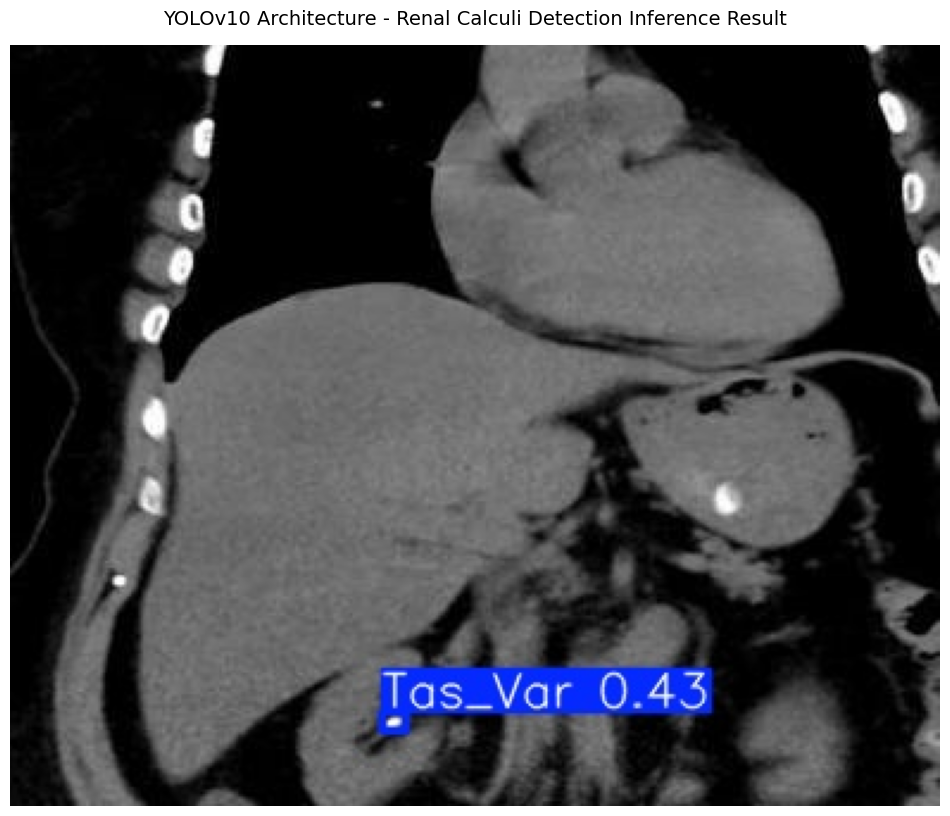

In [ ]:
import cv2
from matplotlib import pyplot as plt
import os

# 1. Model tarafından işlenen en güncel inferans (tahmin) dizininin tespiti
predict_folders = [f for f in os.listdir('/content/runs/detect/') if f.startswith('predict')]
predict_folders.sort()
latest_predict_folder = predict_folders[-1]
predict_dir_path = f'/content/runs/detect/{latest_predict_folder}/'

# 2. İlgili dizindeki inferans çıktısı alınmış test görüntüsünün seçilmesi
image_files = [f for f in os.listdir(predict_dir_path) if f.endswith('.jpg')]
if image_files:
    latest_image_name = image_files[0]
    full_image_path = os.path.join(predict_dir_path, latest_image_name)

    print("[INFO] Bounding Box (Sınırlayıcı Kutu) entegre edilmiş çıktı görüntüsü tespit edildi.")
    print(f"[PATH] Dosya Yolu: {full_image_path}")
    print("[STATUS] YOLOv10 Test Seti İnferans Sonucu Görselleştiriliyor...\n")

    # 3. Görüntünün okunması, renk uzayı dönüşümü (BGR -> RGB) ve Matplotlib ile ekrana basılması
    image = cv2.imread(full_image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Akademik raporlama standartlarına uygun görsel boyutlandırma
    plt.figure(figsize=(12, 10))
    plt.imshow(image)
    plt.title('YOLOv10 Architecture - Renal Calculi Detection Inference Result', fontsize=14, pad=15)
    plt.axis('off') # Eksen çizgilerini kaldırarak medikal görüntü odağını artırma
    plt.show()

else:
    print("[ERROR] Belirtilen dizinde inferans çıktısı alınmış herhangi bir görüntü dosyası (.jpg) bulunamadı.")

In [2]:
# [STATUS] YOLOv11 Nano (yolo11n) Modeli Transfer Learning Eğitimi Başlatılıyor...
from ultralytics import YOLO

# 1. Ön eğitimli YOLOv11 mimarisini yüklüyoruz
model_v11 = YOLO('yolo11n.pt')

# 2. TEKNOFEST standartlarında 50 Epoch'luk medikal eğitimi tetikliyoruz
results_v11 = model_v11.train(
    data='/content/bobrek_verisi/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0, # GPU kullanımı aktif
    name='yolov11_bobrek_50_epoch'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bobrek_verisi/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, i

In [3]:
# [STATUS] YOLOv11 Mimarisi İle Görsel İnferans Testi Başlatılıyor...
from ultralytics import YOLO

# En son eğittiğimiz YOLOv11 modelinin best.pt dosyasını çağırıyoruz
model_v11_test = YOLO('/content/runs/detect/yolov11_bobrek_50_epoch/weights/best.pt')

# Kullandığımız aynı test görüntüsü üzerinde tahmin yürütüyoruz
results_v11_img = model_v11_test.predict(
    source='/content/bobrek_verisi/test/images/1-3-46-670589-33-1-63706052409136049800001-4885266517035478638_png_jpg.rf.403057fc6d27ba2b8a1020faf23ea6e8.jpg',
    save=True,
    imgsz=640,
    conf=0.25
)


image 1/1 /content/bobrek_verisi/test/images/1-3-46-670589-33-1-63706052409136049800001-4885266517035478638_png_jpg.rf.403057fc6d27ba2b8a1020faf23ea6e8.jpg: 544x640 1 Tas_Var, 282.7ms
Speed: 28.4ms preprocess, 282.7ms inference, 4.2ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/detect/predict


In [5]:
# [STATUS] YOLOv11 Modelinin Bağımsız Test Seti Üzerindeki Metrikleri Ölçülüyor...
from ultralytics import YOLO

# En son eğittiğimiz YOLOv11 modelinin best.pt dosyasını çağırıyoruz
model_v11_test = YOLO('/content/runs/detect/yolov11_bobrek_50_epoch/weights/best.pt')

print("[STATUS] YOLOv11 Modeli İçin Test Seti Validasyon Süreci Başlatıldı...\n")
# Modeli dürüstçe sadece 'test' seti üzerinde test ediyoruz
metrics_v11 = model_v11_test.val(data='/content/bobrek_verisi/data.yaml', split='test')

print("\n=======================================================")
print("--- METRIC ANALYSIS: YOLOv11 ARCHITECTURE TEST RESULTS ---")
print(f"Precision (Keskinlik): {metrics_v11.results_dict['metrics/precision(B)']:.4f}")
print(f"Recall (Duyarlılık)  : {metrics_v11.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP50 Skoru          : {metrics_v11.results_dict['metrics/mAP50(B)']:.4f}")
print("=======================================================")

[STATUS] YOLOv11 Modeli İçin Test Seti Validasyon Süreci Başlatıldı...

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 806.2±255.0 MB/s, size: 16.5 KB)
val: Scanning /content/bobrek_verisi/test/labels... 123 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 2.3Kit/s 0.1s
val: New cache created: /content/bobrek_verisi/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.1it/s 2.5s
                   all        123        224      0.808      0.696      0.703      0.308
Speed: 2.9ms preprocess, 5.5ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val

--- METRIC ANALYSIS: YOLOv11 ARCHITECTURE TEST RESULTS ---
Precision (Keskinlik): 0.8076
Recall (Duyarlılık)  : 0.6964
mAP50 Skoru          : 0.7

[INFO] YOLOv11 Sınırlayıcı Kutu (Bounding Box) Çıktısı Görselleştiriliyor...
[PATH] Kaynak Yol: /content/runs/detect/predict/1-3-46-670589-33-1-63706052409136049800001-4885266517035478638_png_jpg.rf.403057fc6d27ba2b8a1020faf23ea6e8.jpg



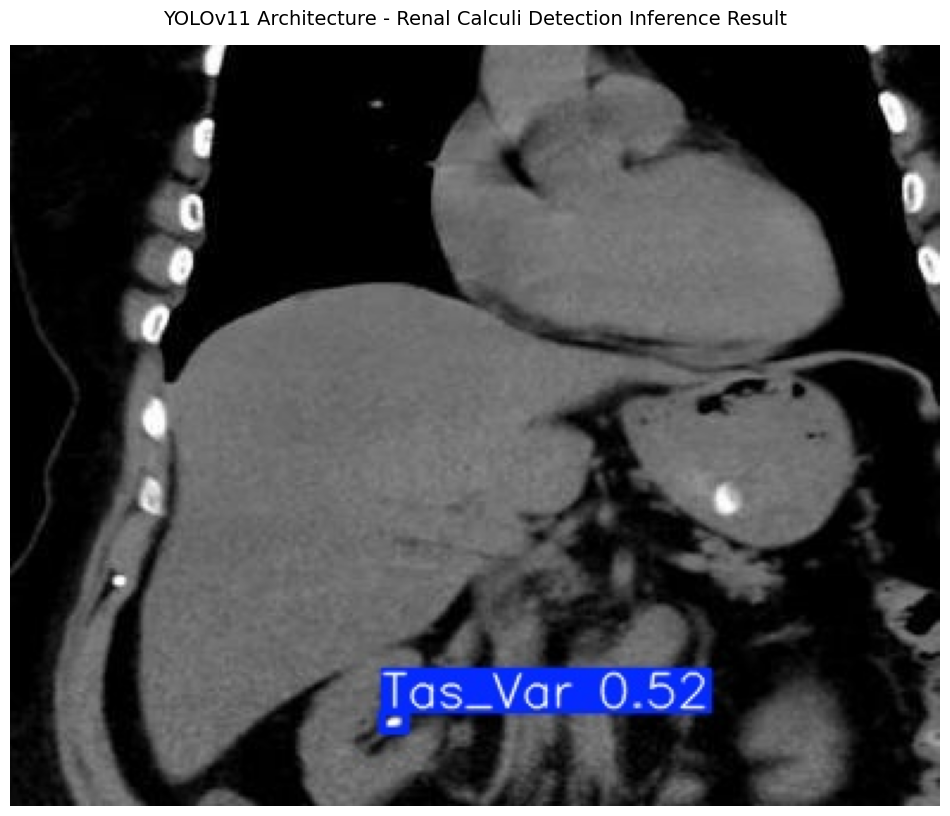

In [4]:
import cv2
from matplotlib import pyplot as plt
import os

# YOLOv11'in oluşturduğu en son tahmin dizinini tespit ediyoruz
predict_folders = [f for f in os.listdir('/content/runs/detect/') if f.startswith('predict')]
predict_folders.sort()
latest_predict_folder = predict_folders[-1]
predict_dir_path = f'/content/runs/detect/{latest_predict_folder}/'

image_files = [f for f in os.listdir(predict_dir_path) if f.endswith('.jpg')]
if image_files:
    full_image_path = os.path.join(predict_dir_path, image_files[0])

    print("[INFO] YOLOv11 Sınırlayıcı Kutu (Bounding Box) Çıktısı Görselleştiriliyor...")
    print(f"[PATH] Kaynak Yol: {full_image_path}\n")

    image = cv2.imread(full_image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 10))
    plt.imshow(image)
    # Akademik poster/rapor başlığı
    plt.title('YOLOv11 Architecture - Renal Calculi Detection Inference Result', fontsize=14, pad=15)
    plt.axis('off')
    plt.show()
else:
    print("[ERROR] İlgili tahmin dizininde çıktı görüntüsü bulunamadı.")

In [7]:
# [STATUS] YOLOv9 Compact (yolov9c) Modeli Eğitimi Başlatılıyor...
from ultralytics import YOLO

# 1. Ön eğitimli YOLOv9 mimarisini yüklüyoruz
model_v9 = YOLO('yolov9c.pt')

# 2. Aynı veri seti ve 50 Epoch'luk parametrelerle eğitimi tetikliyoruz
results_v9 = model_v9.train(
    data='/content/bobrek_verisi/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    name='yolov9_bobrek_50_epoch'
)

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bobrek_verisi/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9_bobrek_50_epoch, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr